# 08 - Discrete-time hazard model (survival framing)

The static classifiers (01-03) score `P(cancel before arrival)` from features known at booking time. This means that the same booking gets the same score regardless of how
close arrival is. In reality, the cancel risk is highly dependent on the days left until booking. This notebook builds a discrete-time **hazard** that re-scores every day.

`h(d) = P(cancel in the window ending d days before arrival | still open at d)`

A booking contributes one row per snapshot it survives to. The snapshot grid is **daily for d = 1..14** (the decision horizon) plus a **coarse tail** (21..270) so long-lead cancellations are not mislabelled as survivors. Per-booking `P(cancel before arrival)` is the survival product `1 - prod(1 - h(d))` over the booking's remaining snapshots.

The heavy logic lives in `src/hazard.py` (unit-tested). This notebook drives it and reports metrics. No-shows are **censored survivors** (reached arrival without cancelling).

## 0 - Setup

In [1]:
from __future__ import annotations
import sys, time
from pathlib import Path
_t0 = time.perf_counter()
def _step(m): print(f"  [{time.perf_counter()-_t0:5.2f}s] {m}", flush=True)

_step("locating project root...")
_here = Path.cwd().resolve()
while not (_here / "pyproject.toml").exists():
    if _here == _here.parent:
        raise RuntimeError("could not find project root")
    _here = _here.parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from src import (load_clean_reservations, color, data_dir, figures_dir, tables_dir)
from src import walkforward as WF
import src.hazard as HZ
import src.scoring as sc

pio.templates.default = "plotly_white"
BRAND = {n: color(n) for n in ["yellow", "blue", "green", "orange", "pink", "purple", "red"]}
FIG_DIR = figures_dir() / "08_hazard"; FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR = tables_dir()  / "08_hazard"; TBL_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80); pd.set_option("display.width", 200)
_step("setup done (plotly).")

  [ 0.00s] locating project root...
  [ 2.02s] setup done (plotly).


## 1 - Load cleaned data + build the survival event columns

`src.hazard.add_event_columns` reads the canonical `cancel_days_before_arrival` from the clean parquet (built in 00 §3.2).

In [2]:
clean = load_clean_reservations()
ce = HZ.add_event_columns(clean)

n_book = len(ce)
n_evt  = int(ce["event_d"].notna().sum())
print(f"resolved bookings:                 {n_book:,}")
print(f"pre-arrival cancel events:         {n_evt:,}  ({n_evt / n_book:.1%})")
print(f"censored survivors (incl no-show): {n_book - n_evt:,}")

ev = ce.loc[ce["event_d"].notna(), "event_d"]
print(f"event timing (days before arrival): median={ev.median():.0f}  "
      f"p90={ev.quantile(0.9):.0f}  max={ev.max():.0f}")

fig = go.Figure()
fig.add_histogram(x=ev.clip(upper=180), nbinsx=60, marker_color=BRAND["blue"])
fig.update_layout(title="When do cancellations happen? (days before arrival)",
                  xaxis_title="days before arrival (capped at 180)",
                  yaxis_title="cancellations", bargap=0.02)
fig.show()

resolved bookings:                 174,644
pre-arrival cancel events:         36,139  (20.7%)
censored survivors (incl no-show): 138,505
event timing (days before arrival): median=7  p90=56  max=364


## 2 - Person-period grid + empirical hazard by horizon

Each booking is expanded to one row per snapshot it survives to where the target is "cancelled within this snapshot's window". Because the coarse snapshots span wider windows, I plot the **per-day** hazard (window rate / window width) so daily and coarse snapshots are comparable.

In [3]:
num, cat = HZ.feature_lists(clean)
print(f"features: {len(num)} numeric + {len(cat)} categorical")
print(f"snapshot grid (daily 1..14 + coarse tail): {HZ.SNAP}")

pp, _ = HZ.build_person_period(ce, num, cat)
g = pp.groupby(HZ.AXIS).agg(haz=("y", "mean"), width=("width", "first"), n=("y", "size"))
g["haz_per_day"] = g["haz"] / g["width"]          # width-normalised => comparable across snapshots
print(f"person-period rows: {len(pp):,}")

fig = go.Figure()
fig.add_bar(x=g.index, y=g["haz_per_day"], marker_color=BRAND["blue"])
fig.update_layout(title="Per-day cancellation hazard by days-until-arrival (width-normalised)",
                  xaxis_title="days until arrival (snapshot d)",
                  yaxis_title="P(cancel per day | at risk)")
fig.update_xaxes(autorange="reversed")
fig.show()

features: 14 numeric + 7 categorical
snapshot grid (daily 1..14 + coarse tail): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 21, 30, 45, 60, 90, 120, 180, 270]
person-period rows: 1,435,302


## 3 - Fit + persist the deployment hazard model

`retrain_hazard` fits on **all resolved** data with a RandomizedSearch (XGBoost, early stopping) and **per-snapshot-band isotonic calibration** (a daily-band map and a coarse-tail map - a wide-window hazard is not on the same scale as a dailyone, so one pooled map would miscalibrate both), then persists the joblib + card that the app's retrain path uses. We reload the artifact for the diagnostics below.

In [4]:
_step("fitting + persisting deployment hazard (early stopping; minutes)...")
res = HZ.retrain_hazard(seed=RANDOM_STATE)
hz  = HZ.load_hazard()
print("persisted ->", res["persisted"]["joblib"])
print("card      ->", res["persisted"]["card"])
print(f"val AP = {hz['val_ap']:.4f} | best_iteration = {hz['best_iteration']} | "
      f"person-period train rows = {hz['n_train_pp']:,}")
print(f"chosen hp: {hz['hp']}")
print(f"calibration bands: edge d={hz['iso_bands']['edge']} "
      f"(separate daily / coarse-tail maps)")

  [19.27s] fitting + persisting deployment hazard (early stopping; minutes)...
persisted -> /Users/ruby.grambauer/Documents/DEV/overbookinganalyses/Data/08_hazard_model.joblib
card      -> /Users/ruby.grambauer/Documents/DEV/overbookinganalyses/reports/tables/08_hazard/model_card.json
val AP = 0.0766 | best_iteration = 231 | person-period train rows = 1,250,489
chosen hp: {'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 5, 'reg_lambda': 1.0, 'subsample': 0.8, 'colsample_bytree': 0.8}
calibration bands: edge d=14 (separate daily / coarse-tail maps)


## 4 - Per-band calibration maps

The two isotonic maps translate the raw XGBoost score into a calibrated hazard. They differ because the daily and coarse-tail snapshots carry different window widths and base rates.

In [5]:
b = hz["iso_bands"]
grid = np.linspace(0.0, 0.35, 200)
fig = go.Figure()
fig.add_scatter(x=grid, y=b["le"].predict(grid), mode="lines",
                line=dict(color=BRAND["blue"]),   name=f"daily band (d <= {b['edge']})")
fig.add_scatter(x=grid, y=b["gt"].predict(grid), mode="lines",
                line=dict(color=BRAND["orange"]), name=f"coarse tail (d > {b['edge']})")
fig.add_scatter(x=grid, y=grid, mode="lines",
                line=dict(color="grey", dash="dash"), name="identity")
fig.update_layout(title="Per-band isotonic calibration (raw score -> calibrated hazard)",
                  xaxis_title="raw model score", yaxis_title="calibrated hazard")
fig.show()

## 5 - Matched walk-forward: hazard vs static (apples-to-apples)

Both models are scored on the **same** decision-time rows - each booking once, at its decision date `S* = max(created, arrival - 14)` if still open, scored at horizon `min(lead, 14)` (as in 00 §12) - against the **same** label (`cancel by arrival`), so they estimate the same quantity. Short-lead bookings are included (median lead ~11d). The promotion signal is `mean(ΔAUC) > its own std` (beats noise), not a magic 0.01 gate.

In [6]:
_step("matched decision-time walk-forward (hazard vs static; heavy)...")
wf = HZ.walk_forward_eval_hazard(n_folds=12, horizon_days=14, step_days=14,
                                 compare_static=True, seed=RANDOM_STATE)
pf = pd.DataFrame(wf["per_fold"])
display(pf)
print("aggregate:", {k: round(v["mean"], 4) for k, v in wf["aggregate"].items()})
print("promotion gate (mean ΔAUC > its std):", wf["gate"])
pf.to_csv(TBL_DIR / "hazard_vs_static_walkforward.csv", index=False)

if "auc_static" in pf.columns:
    fig = go.Figure()
    fig.add_scatter(x=pf["S"], y=pf["auc_haz"],    mode="lines+markers",
                    line=dict(color=BRAND["blue"]),   name="hazard")
    fig.add_scatter(x=pf["S"], y=pf["auc_static"], mode="lines+markers",
                    line=dict(color=BRAND["orange"]), name="static baseline")
    fig.update_layout(title="Matched walk-forward AUC (same rows / same label)",
                      xaxis_title="scoring date S", yaxis_title="AUC (cancel before arrival)")
    fig.show()

  [1565.96s] matched decision-time walk-forward (hazard vs static; heavy)...


,fold,S,n_test,auc_haz,ap_haz,brier_haz
0,0,2026-01-25,2614,0.724235,0.279162,0.108855
1,1,2026-02-08,2768,0.694395,0.320415,0.123183
2,2,2026-02-22,2925,0.729077,0.287869,0.095869
3,3,2026-03-08,2598,0.720736,0.295087,0.097859
4,4,2026-03-22,2371,0.752152,0.296461,0.096345
5,5,2026-04-05,3026,0.683794,0.270593,0.116379
6,6,2026-04-19,2953,0.730348,0.316380,0.105360
7,7,2026-05-03,3146,0.736602,0.281404,0.103369
8,8,2026-05-17,3394,0.755441,0.308778,0.090284
9,9,2026-05-31,3507,0.766042,0.373968,0.097247


aggregate: {'auc_haz': 0.7289, 'ap_haz': 0.2925, 'brier_haz': 0.0983}
promotion gate (mean ΔAUC > its std): None


## 6 - Calibration: is the probability trustworthy?

Two different questions, often confused:

**(a) Per-booking calibration** - when the model says 12%, do ~12% of such bookings
cancel? The raw Brier looks small (~0.10) but that is not skill: at a ~12% base rate
the *irreducible* Uncertainty is `p0(1-p0) ≈ 0.108`, so Brier ≈ 0.10 just means "near
the best possible". Read the **Murphy decomposition** `Brier = Uncertainty − Resolution
+ Reliability` and the **Brier Skill Score** `BSS = 1 − Brier/Uncertainty`. Judge
calibration by **Reliability** (≈0 = perfect), not by raw Brier.

In [7]:
from sklearn.calibration import calibration_curve
_step("pooled per-booking hazard predictions (heavy)...")
oos = HZ.walk_forward_predict_hazard(n_folds=6, horizon_days=14, step_days=14, seed=RANDOM_STATE)
yv, pv = oos["y_true"].to_numpy(), np.clip(oos["y_prob"].to_numpy(), 0, 1)
d = sc.brier_decomposition(yv, pv)
print(f"pooled per-booking (n={len(oos):,}, base rate {d['base_rate']:.3f}):")
print(f"  Brier       = {d['brier']:.4f}   (Uncertainty p0(1-p0) = {d['uncertainty']:.4f}, irreducible)")
print(f"  Reliability = {d['reliability']:.5f}   <- calibration error, near 0 = well calibrated")
print(f"  Resolution  = {d['resolution']:.5f}   <- skill (how far bins sit from the base rate)")
print(f"  BSS         = {d['bss']:.3f}   <- vs the base-rate predictor (small at low prevalence is normal)")
frac, mean_p = calibration_curve(yv, pv, n_bins=10, strategy="quantile")
fig = go.Figure()
fig.add_scatter(x=mean_p, y=frac, mode="lines+markers", name="hazard", line=dict(color=BRAND["blue"]))
fig.add_scatter(x=[0, float(mean_p.max())], y=[0, float(mean_p.max())], mode="lines",
                line=dict(color="grey", dash="dash"), name="perfect")
fig.update_layout(title="Per-booking reliability (pooled OOS)",
                  xaxis_title="mean predicted", yaxis_title="observed frequency")
fig.show()

  [8878.97s] pooled per-booking hazard predictions (heavy)...
pooled per-booking (n=17,726, base rate 0.118):
  Brier       = 0.0935   (Uncertainty p0(1-p0) = 0.1043, irreducible)
  Reliability = 0.00052   <- calibration error, near 0 = well calibrated
  Resolution  = 0.01007   <- skill (how far bins sit from the base rate)
  BSS         = 0.103   <- vs the base-rate predictor (small at low prevalence is normal)


**(b) Per-night aggregate calibration - what overbooking actually needs.** Sum the
per-booking probabilities over an arrival night → expected freed rooms, with the
Poisson-binomial variance `Σ p(1-p)`. Even when (a) is fine, two things bite: a tiny
per-booking bias becomes a **material % bias** once summed (fix: a multiplicative
`recalibration_factor` fit on validation), and cancellations are **correlated** within
a night (events, groups) → real variance > Poisson-binomial → **overdispersion φ>1** →
naïve intervals too narrow (fix: widen sd by √φ). Both need MANY nights - the old cell
used one fold (~14 nights = noise); we **pool over all folds**.

In [8]:
_step("pooled per-night calibration (heavy)...")
pn = HZ.walk_forward_per_night(n_folds=6, horizon_days=14, step_days=14, seed=RANDOM_STATE)
cov = HZ.coverage_report(pn); r = HZ.recalibration_factor(pn)
print(f"pooled per-night (n_nights={len(pn):,}):")
print(f"  overdispersion phi = {cov['phi']:.2f}  (>1 => correlated cancellations; widen sd by sqrt(phi) = {cov['phi']**0.5:.1f}x)")
print(f"  aggregate bias      = {cov['bias_pct']:+.1f}%   -> multiplicative recalibration factor = {r:.3f}")
for lvl in (50, 90, 95):
    print(f"  coverage @ {lvl}%: raw {cov.get(f'cov{lvl}', float('nan')):.2f}  vs  sqrt(phi)-adjusted {cov.get(f'cov{lvl}_adj', float('nan')):.2f}")
pn2 = pn.sort_values("arrival_date")
fig = go.Figure()
fig.add_scatter(x=pn2["arrival_date"], y=pn2["exp"], mode="markers", marker=dict(color=BRAND["blue"], size=4), name="expected freed")
fig.add_scatter(x=pn2["arrival_date"], y=pn2["act"], mode="markers", marker=dict(color=BRAND["orange"], size=4), name="actual freed")
fig.add_scatter(x=pn2["arrival_date"], y=pn2["exp"]*r, mode="markers", marker=dict(color=BRAND["green"], size=4), name=f"recalibrated (x{r:.2f})")
fig.update_layout(title="Per-arrival-night expected vs actual freed rooms (pooled over folds)",
                  xaxis_title="arrival night", yaxis_title="rooms freed (cancel before arrival)")
fig.show()

  [12137.16s] pooled per-night calibration (heavy)...


pooled per-night (n_nights=154):
  overdispersion phi = 4.26  (>1 => correlated cancellations; widen sd by sqrt(phi) = 2.1x)
  aggregate bias      = -15.5%   -> multiplicative recalibration factor = 1.183
  coverage @ 50%: raw 0.28  vs  sqrt(phi)-adjusted 0.49
  coverage @ 90%: raw 0.60  vs  sqrt(phi)-adjusted 0.88
  coverage @ 95%: raw 0.69  vs  sqrt(phi)-adjusted 0.90


## 7 - Time-resolved accuracy: does the hazard track risk over time?

The matched walk-forward (§5) grades each booking once, at its decision horizon. That measures the *decision*, not whether the model captures how risk **changes** as arrival approaches. Here we score each fold's TEST bookings at every daily snapshot (`src.hazard.walk_forward_per_snapshot`) and report discrimination + calibration **per days-until-arrival**. Only the daily band (d = 1..14) is evaluable: a decision-time test set is open at S* = arrival-14, so it is survivor-selected and holds no events beyond 14 days (the coarse tail is a training aid for long-lead bookings, exercised via the per-booking survival product). Very honestly said - I am not sure if this is statistically 100% legal. In production we care only about predicting accurately 14 days before arrival is supposed to happen - already existing cancellations are resolved and integrated into the occupancy therefore I chose to exclude anything that is not actually used in production.

In [ ]:
_step("time-resolved per-snapshot walk-forward (heavy)...")
ps = HZ.walk_forward_per_snapshot(n_folds=6, horizon_days=14, step_days=14, seed=RANDOM_STATE)
m = ps["per_snapshot"]
display(m.round(4))

fig = go.Figure()
fig.add_scatter(x=m["days_until_arrival"], y=m["emp_hazard"], mode="lines+markers",
                line=dict(color=BRAND["blue"]),   name="empirical")
fig.add_scatter(x=m["days_until_arrival"], y=m["pred_hazard"], mode="lines+markers",
                line=dict(color=BRAND["orange"]), name="predicted")
fig.update_layout(title="Time-resolved calibration: daily hazard by days-until-arrival",
                  xaxis_title="days until arrival", yaxis_title="P(cancel in window | at risk)")
fig.update_xaxes(autorange="reversed"); fig.show()

fig = go.Figure(go.Bar(x=m["days_until_arrival"], y=m["auc"], marker_color=BRAND["green"]))
fig.update_layout(title="Per-horizon discrimination (AUC) of the daily hazard",
                  xaxis_title="days until arrival", yaxis_title="AUC")
fig.update_xaxes(autorange="reversed"); fig.show()
print(f"  mean per-horizon AUC (d=1..14): {m['auc'].mean():.3f}")

  [17402.28s] time-resolved per-snapshot walk-forward (heavy)...


## 8 - Explainability (XAI): what drives the hazard, and the time effect

Feature importance (XGBoost gain) plus the model's learned **marginal hazard vs
days-until-arrival** - the time signal a static model cannot represent.

In [ ]:
# (1) Feature importance (gain). Order matches the training FEATS = num + [axis] + cat.
fnames = hz["num"] + ["days_until_arrival"] + hz["cat"]
imp = pd.DataFrame({"feature": fnames, "importance": hz["model"].feature_importances_}) \
        .sort_values("importance", ascending=False).head(15)
fig = go.Figure(go.Bar(x=imp["importance"][::-1], y=imp["feature"][::-1],
                       orientation="h", marker_color=BRAND["blue"]))
fig.update_layout(title="Hazard feature importance (XGBoost gain)", xaxis_title="gain")
fig.show()

# (2) Marginal effect of days-until-arrival on the calibrated hazard (partial dependence).
samp = clean.sample(n=min(4000, len(clean)), random_state=1)
ce_x = HZ.add_event_columns(samp)
pp_x, _ = HZ.build_person_period(ce_x, hz["num"], hz["cat"], cat_dtypes=hz["cat_dtypes"])
base = pp_x.drop_duplicates("src_idx").head(2000).copy()
FEATS = hz["num"] + [HZ.AXIS] + hz["cat"]; haz = HZ.hazard_fn(hz)
grid_d = list(range(1, 15))
pdp = [float(np.mean(haz(base.assign(**{HZ.AXIS: float(d)})[FEATS]))) for d in grid_d]
fig = go.Figure(go.Scatter(x=grid_d, y=pdp, mode="lines+markers", line=dict(color=BRAND["orange"])))
fig.update_layout(title="Marginal hazard vs days-until-arrival (learned time effect)",
                  xaxis_title="days until arrival", yaxis_title="mean calibrated hazard")
fig.update_xaxes(autorange="reversed"); fig.show()

## Rigorous scoring diagnostics - Hazard vs. baseline (+ SHAP)
Same standard battery on the pooled per-booking hazard OOS predictions (`yv`, `pv`): mean-rate baseline, ROC/AUC, precision–recall/AP, confusion matrix, precision/recall/F1 vs. threshold, and SHAP on the underlying booster.


In [ ]:
import src.diagnostics as diag
thr_h = sc.cost_threshold_from_scores(yv, pv)   # cost-optimal threshold on the pooled OOS
diag.print_report(yv, pv, model_name='hazard', threshold=thr_h)
diag.roc_curve_fig(yv, pv, 'hazard').show()
diag.pr_curve_fig(yv, pv, 'hazard').show()
diag.confusion_fig(yv, pv, thr_h, 'hazard').show()
diag.threshold_sweep_fig(yv, pv, thr_h).show()

=== Scoring diagnostics: hazard  (n=17,559, threshold=0.761) ===
          metric  hazard baseline
         ROC-AUC  0.7365      0.5
           PR-AP  0.3047   0.1256
           Brier  0.0998   0.1098
        log-loss  0.5442    0.378
precision @ 0.76  0.9048         
   recall @ 0.76  0.0086         
       F1 @ 0.76  0.0171         
 accuracy @ 0.76  0.8753         
  base rate (p0)  0.1256   0.1256

Confusion @ 0.761:  TP=19  FP=2  FN=2187  TN=15351


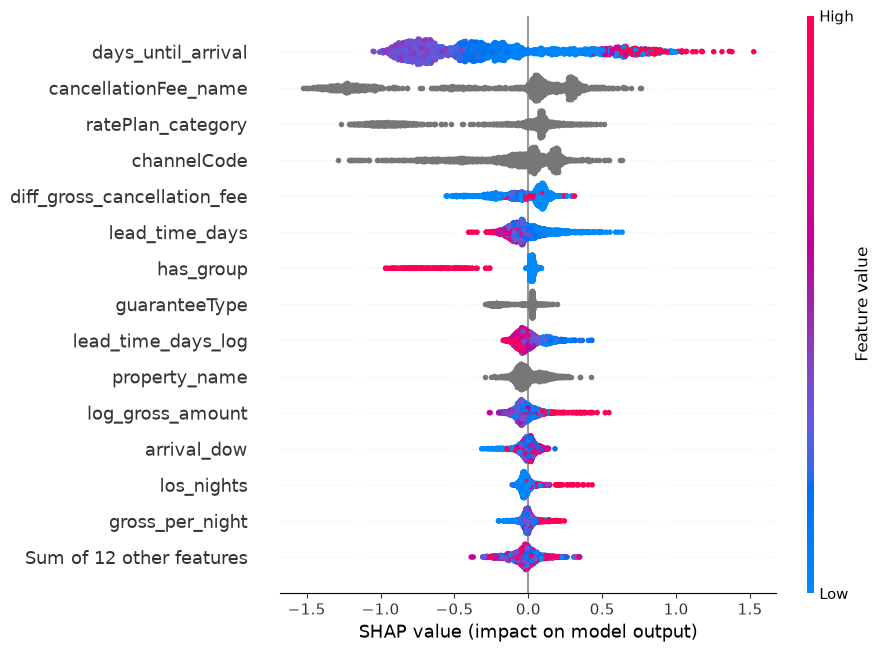

In [ ]:
# SHAP on the hazard model's underlying booster (hz['model'], a plain XGBClassifier),
# over the person-period design = features + the day axis. Degrades gracefully if SHAP
# can't explain the categorical-enabled booster.
samp = clean.sample(n=min(3000, len(clean)), random_state=RANDOM_STATE)
ce = HZ.add_event_columns(samp)
pp, _ = HZ.build_person_period(ce, hz['num'], hz['cat'], cat_dtypes=hz['cat_dtypes'])
FEATS = hz['num'] + [HZ.AXIS] + hz['cat']
design = pp[FEATS]
fig = diag.shap_bar_fig(hz['model'], design, FEATS, title='Hazard SHAP (mean |value|)')
fig.show() if fig is not None else print('SHAP unavailable - see warning above')
diag.shap_beeswarm(hz['model'], design, FEATS)